Step 1 - setup and feature extraction

In [ ]:
# step 1 - setup and feature extraction
import torch
import torchvision.transforms as transforms, torchvision
from torchvision.models.resnet import resnet18
import torchvision
import torchvision.transforms as transforms
from simclr import SimCLR
from simclr.modules import NT_Xent
import numpy as np



# augmentations will need to be done here
# random resized crops - The algorithm takes a random section of the image
#  and resizes it back to the standard 32x32 pixel size
# Random horizontal flips
# Color jittering
# Random grayscaling


class ContrastiveTransformations(object):

    def __init__(self, base_transforms, n_views=2):
        self.base_transforms = base_transforms
        self.n_views = n_views

    def __call__(self, x):
        return [self.base_transforms(x) for i in range(self.n_views)]

base_transform = transforms.Compose([
    
    transforms.RandomResizedCrop(size=32),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(0.5, 0.5, 0.5, 0.2),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor()
])



print("Downloading CIFAR 10")
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=ContrastiveTransformations(base_transform)
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    drop_last=True
)


encoder = resnet18()
n_features = encoder.fc.in_features
model = SimCLR(encoder, projection_dim=128, n_features=n_features)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch is currently running on: {device}") 
model = model.to(device)

optimiser = torch.optim.SGD(
    model.parameters(),
    lr=0.4,
    momentum=0.9,
    weight_decay=0.0001
)



# things to do
# use cosine thing for the learning rate




criterion = NT_Xent(batch_size=512, temperature=0.5, world_size=1)
epochs = 300
patience = 20
best_loss = float('inf')
patience_counter = 0

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimiser, T_max=epochs)


for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_idx, (images, _) in enumerate(train_loader):
        view1 = images[0].to(device)
        view2 = images[1].to(device)
        
        # 1. Wipe the old math memory
        optimiser.zero_grad()
        hi, hj, zi, zj = model(view1, view2)

        loss = criterion(zi, zj)

        loss.backward()

        optimiser.step()

        total_loss+= loss.item()

        if batch_idx % 50 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx}/{len(train_loader)}], Loss: {loss.item():.4f}")

    avg_epoch_loss = total_loss / len(train_loader)
    print(f"--- End of Epoch {epoch+1} | Average Loss: {avg_epoch_loss:.4f} ---")

    scheduler.step()

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0 # Reset the strike counter!
        print("New best loss! Saving progress...")
        torch.save(model.state_dict(), 'best_simclr_model.pth')
    else:
        patience_counter += 1 # Add a strike
        print(f"Loss did not improve. Patience: {patience_counter}/{patience}")

    # If we hit our strike limit, pull the emergency brake!
    if patience_counter >= patience:
        print(f"Early stopping triggered! The model stopped learning at epoch {epoch+1}.")
        break # This f


Files already downloaded and verified
PyTorch is currently running on: cuda
Epoch [1/50], Batch [0/97], Loss: 6.8913
Epoch [1/50], Batch [50/97], Loss: 6.3649
--- End of Epoch 1 | Average Loss: 6.3961 ---
New best loss! Saving progress...
Epoch [2/50], Batch [0/97], Loss: 6.2151
Epoch [2/50], Batch [50/97], Loss: 6.1917
--- End of Epoch 2 | Average Loss: 6.1727 ---
New best loss! Saving progress...
Epoch [3/50], Batch [0/97], Loss: 6.1278
Epoch [3/50], Batch [50/97], Loss: 6.0985
--- End of Epoch 3 | Average Loss: 6.0964 ---
New best loss! Saving progress...
Epoch [4/50], Batch [0/97], Loss: 6.0322
Epoch [4/50], Batch [50/97], Loss: 6.0494
--- End of Epoch 4 | Average Loss: 6.0402 ---
New best loss! Saving progress...
Epoch [5/50], Batch [0/97], Loss: 5.9827
Epoch [5/50], Batch [50/97], Loss: 5.9996
--- End of Epoch 5 | Average Loss: 5.9996 ---
New best loss! Saving progress...
Epoch [6/50], Batch [0/97], Loss: 5.9960
Epoch [6/50], Batch [50/97], Loss: 5.9980
--- End of Epoch 6 | Avera

In [3]:
torch.save(model.state_dict(), 'best_simclr_model_manual_save.pth')
print("Model successfully rescued and saved to hard drive!")

Model successfully rescued and saved to hard drive!


In [1]:
import torch.nn.functional as F
from simclr import SimCLR
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models.resnet import resnet18

# 1. Setup the device (just in case you run this tomorrow)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Build the empty shell 
encoder = resnet18()
n_features = encoder.fc.in_features
loaded_model = SimCLR(encoder, projection_dim=128, n_features=n_features)
loaded_model = loaded_model.to(device)

# 3. Load the saved brain
saved_weights_path = 'best_simclr_model_manual_save.pth'
loaded_model.load_state_dict(torch.load(saved_weights_path, map_location=device, weights_only=True))
loaded_model.eval()

# clean transform

clean_transform = transforms.Compose([
    transforms.ToTensor()
])

clean_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=clean_transform
)

clean_loader = torch.utils.data.DataLoader(
    clean_dataset,
    batch_size=512,
    shuffle=False
)


loaded_model.eval()

all_features = []
all_labels = []

with torch.no_grad():
    print("Features")

    for images, labels in clean_loader:
        images = images.to(device)
        
        features = encoder(images)

        all_features.append(features.cpu())
        all_labels.append(labels.cpu())


all_features = torch.cat(all_features, dim=0)
all_labels = torch.cat(all_labels, dim=0)

all_features_normalized = F.normalize(all_features, p=2, dim=1)

print(f"Extraction complete! Final array shape: {all_features_normalized.shape}")

c:\Users\arnav\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Features
Extraction complete! Final array shape: torch.Size([50000, 512])


In [ ]:
from sklearn.cluster import KMeans
import numpy as np
# k means clustering

label_budget = 3

k_means_algorithm = KMeans(n_clusters=label_budget, random_state=42, n_init='auto')

k_means_algorithm.fit(all_features_normalized)

final_typical_images = []

from sklearn.neighbors import NearestNeighbors

cluster_assignments = k_means_algorithm.labels_

nearest = NearestNeighbors(n_neighbors=20,algorithm='ball_tree')

for i in range(label_budget):
    cluster_i = np.where(cluster_assignments == i)[0]

    cluster_features = all_features_normalized[cluster_i]

    fit = nearest.fit(cluster_features)

    distance, indicies = fit.kneighbors(cluster_features)


    average_distances = distance.mean(axis=1)

    

    typicality_score = 1 / average_distances



    best = np.argmax(typicality_score)

    best_id = cluster_i[best]

    final_typical_images.append(best_id)

    print(f"Cluster {i} winner: Image #{best_id}")


print("All done! Here are your 7 typical images:", final_typical_images)

Cluster 0 winner: Image #26783
Cluster 1 winner: Image #12071
Cluster 2 winner: Image #24916
All done! Here are your 7 typical images: [np.int64(26783), np.int64(12071), np.int64(24916)]


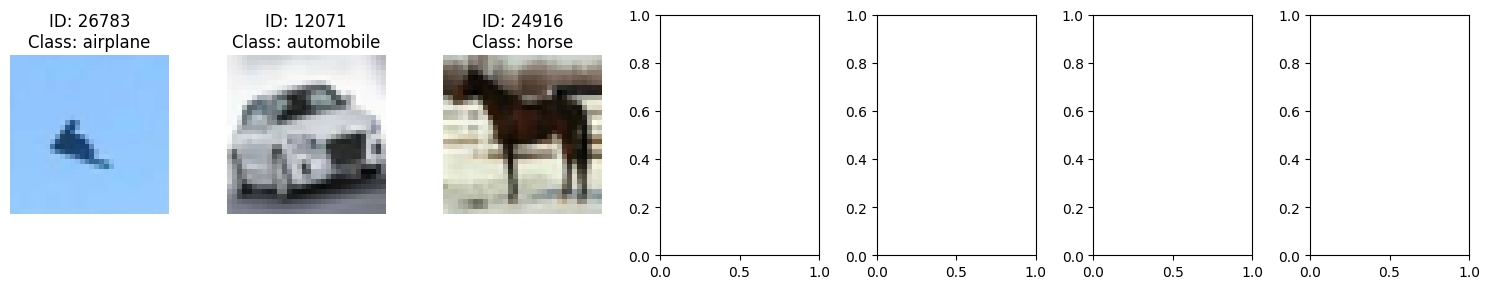

In [10]:
import matplotlib.pyplot as plt

#final_typical_images = [42076, 26315, 24916, 32635, 12071, 41009, 26783]   

fig, axes = plt.subplots(1, 7, figsize=(15, 3))

for idx, image_id in enumerate(final_typical_images):
 
    img_tensor, true_label_id = clean_dataset[image_id]
    
  
    class_name = clean_dataset.classes[true_label_id]
    
  
    img_display = np.transpose(img_tensor.numpy(), (1, 2, 0))
    
   
    axes[idx].imshow(img_display)
    axes[idx].set_title(f"ID: {image_id}\nClass: {class_name}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

Running t-SNE... this takes a few minutes!
t-SNE complete!


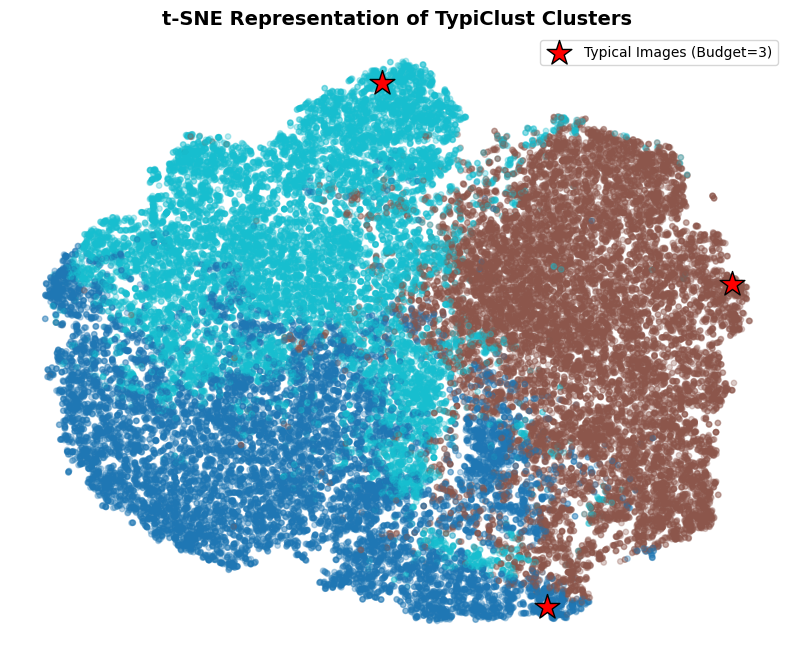

In [9]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 1. Convert your PyTorch tensor into a NumPy array for Scikit-Learn
features_to_plot = all_features_normalized.numpy()

# 2. The Heavy Math
print("Running t-SNE... this takes a few minutes!")
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
features_2d = tsne.fit_transform(features_to_plot)
print("t-SNE complete!")

# 3. Set up the canvas
plt.figure(figsize=(10, 8))

# 4. Plot all 50,000 background dots
# You already generated 'cluster_assignments' in your loop above!
plt.scatter(
    features_2d[:, 0], 
    features_2d[:, 1], 
    c=cluster_assignments, 
    cmap='tab10', 
    alpha=0.3, 
    s=15       
)

# 5. Highlight the 7 typical images you found
typical_x = features_2d[final_typical_images, 0]
typical_y = features_2d[final_typical_images, 1]

plt.scatter(
    typical_x, 
    typical_y, 
    c='red', 
    marker='*', 
    s=350, 
    edgecolor='black',
    label=f'Typical Images (Budget={label_budget})'
)

# 6. Formatting
plt.title("t-SNE Representation of TypiClust Clusters", fontsize=14, fontweight='bold')
plt.legend()
plt.axis('off') 

# Save directly to your folder for Overleaf
plt.savefig('tsne_typiclust.png', dpi=300, bbox_inches='tight')
plt.show()